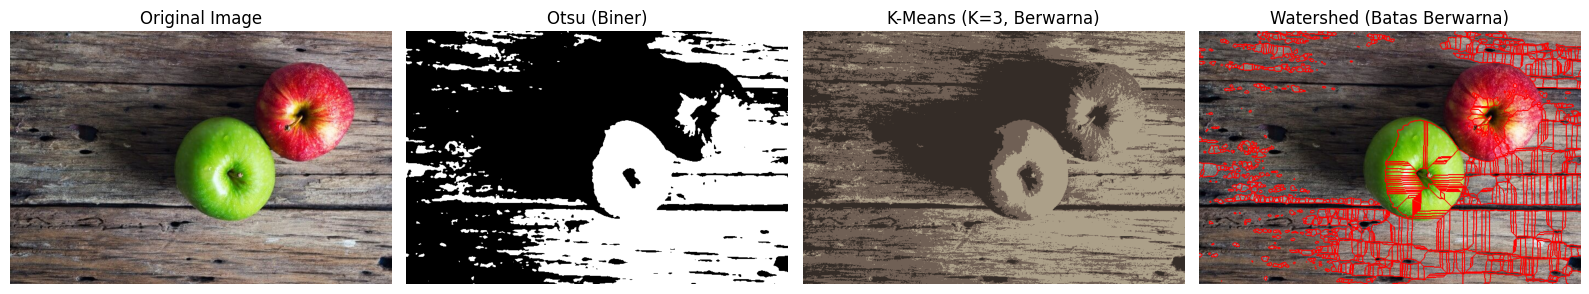

Otsu threshold: 0.4180
Otsu (blur) menghasilkan mask biner: 138557 piksel foreground
K-Means (K=3) mengklaster RGB space ke 3 cluster, ditampilkan berwarna
Watershed menghasilkan 1147 region terpisah dengan batas berwarna

Catatan perbandingan:
- Otsu: hasil biner sederhana, cepat, cocok jika latar homogen dan blur membantu stabilitas
- K-Means: hasil berwarna berdasarkan centroid RGB setiap cluster, fleksibel untuk warna berbeda
- Watershed: batas region ditampilkan berwarna di atas citra asli, detail pada objek terhubung


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, morphology, segmentation, feature, img_as_float
from scipy import ndimage as ndi
from sklearn.cluster import KMeans
import warnings

# Baca citra yang disediakan (penugasan4.jpg)
img = io.imread('penugasan4.jpg')
imgf = img_as_float(img)
gray = color.rgb2gray(imgf)

# 1) Otsu thresholding pada grayscale dengan Gaussian blur
# Blur membantu mengurangi noise sehingga threshold lebih stabil
gray_blur = filters.gaussian(gray, sigma=1.5)
th_otsu = filters.threshold_otsu(gray_blur)
mask_otsu = gray_blur > th_otsu

# 2) K-Means pada ruang warna (RGB) dengan K=3 - TAMPILKAN BERWARNA
# K=3 memberikan segmentasi yang lebih terdetail dibanding K=2
H, W = imgf.shape[:2]
X = imgf.reshape(-1, 3)
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(X)
labels = pixel_labels.reshape(H, W)

# Buat citra K-Means berwarna dengan warna cluster centers
segmented_kmeans_color = np.zeros_like(imgf)
for k in range(3):
    mask_k = (labels == k)
    # Ambil centroid dari cluster k (sudah dalam range 0-1 dari KMeans)
    segmented_kmeans_color[mask_k] = kmeans.cluster_centers_[k]

# 3) Watershed berbasis distance transform - TAMPILKAN BERWARNA dengan boundaries
# Threshold bersih: gunakan Otsu pada blur untuk marker yang lebih stabil
mask_ws_base = gray_blur > th_otsu
distance = ndi.distance_transform_edt(mask_ws_base)
local_maxi = feature.peak_local_max(distance, footprint=np.ones((3,3)))
markers = np.zeros_like(distance, dtype=bool)
markers[tuple(local_maxi.T)] = True
markers = morphology.label(markers)
# Terapkan watershed dengan mask untuk menghindari over-segmentation
labels_ws = segmentation.watershed(-distance, markers, mask=mask_ws_base)

# Visualisasi hasil dengan warna
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Panel 1: Citra original
axes[0].imshow(imgf)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Panel 2: Otsu - tetap biner hitam-putih
axes[1].imshow(mask_otsu, cmap='gray')
axes[1].set_title('Otsu (Biner)')
axes[1].axis('off')

# Panel 3: K-Means - BERWARNA dengan cluster centers
axes[2].imshow(segmented_kmeans_color)
axes[2].set_title('K-Means (K=3, Berwarna)')
axes[2].axis('off')

# Panel 4: Watershed - BERWARNA dengan mark_boundaries
segmented_ws_colored = segmentation.mark_boundaries(imgf, labels_ws, color=(1, 0, 0), mode='thick')
axes[3].imshow(segmented_ws_colored)
axes[3].set_title('Watershed (Batas Berwarna)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# Ringkas perbandingan hasil
print(f'Otsu threshold: {th_otsu:.4f}')
print(f'Otsu (blur) menghasilkan mask biner: {mask_otsu.sum()} piksel foreground')
print(f'K-Means (K=3) mengklaster RGB space ke {len(np.unique(labels))} cluster, ditampilkan berwarna')
print(f'Watershed menghasilkan {labels_ws.max()} region terpisah dengan batas berwarna')
print()
print('Catatan perbandingan:')
print('- Otsu: hasil biner sederhana, cepat, cocok jika latar homogen dan blur membantu stabilitas')
print('- K-Means: hasil berwarna berdasarkan centroid RGB setiap cluster, fleksibel untuk warna berbeda')
print('- Watershed: batas region ditampilkan berwarna di atas citra asli, detail pada objek terhubung')